In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import numpy as np
import torch
from tqdm.auto import tqdm
import torch.nn as nn
import yaml
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../models"))

from dataset import get_data_loaders
from backbone import BackBone
from multiheadmodel import MultiHeadModel
from utils import deterministic, train

### Plots

In [ ]:
path = "../results/backbone_history.yaml"
with open(path, "r") as f:
    backbone_history = yaml.safe_load(f)

fontsize = 14
fig = plt.figure(figsize=(14, 6))
plt.plot(backbone_history["loss"], label="train support acc")
plt.xlabel("Epoch", fontsize=fontsize)
plt.ylabel("Loss", fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.grid(True)

fig.tight_layout()
path = "../images/backbone_training.png"
os.makedirs(os.path.dirname(path), exist_ok=True)
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

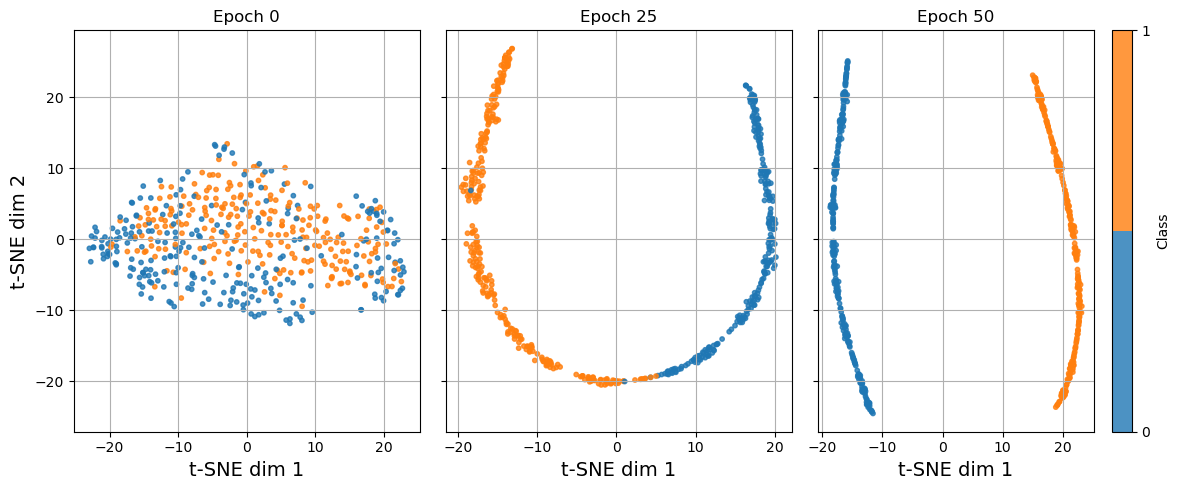

In [16]:
tsne_path = "../results/backbone_tsne.npz"
with np.load(tsne_path) as data:
    tsne_embeddings = data["embeddings"]
    tsne_labels = data["labels"]
    snapshot_epochs = data["epochs"]

fig, axes = plt.subplots(1, tsne_embeddings.shape[0], figsize=(12, 5), sharey=True)

cmap2 = ListedColormap(["tab:blue", "tab:orange"])

for i, ax in enumerate(axes):
    scatter = ax.scatter(
        tsne_embeddings[i, :, 0],
        tsne_embeddings[i, :, 1],
        c=tsne_labels[i],
        cmap=cmap2,
        s=10,
        alpha=0.8,
        vmin=0,
        vmax=1
    )

    ax.set_title(f"Epoch {int(snapshot_epochs[i])}")
    ax.set_xlabel("t-SNE dim 1", fontsize=14)

    if i == 0:
        ax.set_ylabel("t-SNE dim 2", fontsize=14)

    if i == len(axes) - 1:
        cbar = fig.colorbar(scatter, ax=ax, ticks=[0, 1], label="Class")
        cbar.ax.set_yticklabels(["0", "1"])

    ax.grid(True)

fig.tight_layout()

path = "../images/backbone_training_tsnes.png"
os.makedirs(os.path.dirname(path), exist_ok=True)
fig.savefig(path, dpi=300, bbox_inches="tight")

plt.show()

### Training with classifier

In [ ]:
backbone= BackBone()
backbone.load_state_dict(torch.load("../models/weights/backbone.pth"))
model = MultiHeadModel(backbone)
model.add_head(0, 2)

In [ ]:
for param in model.backbone.parameters(): 
    param.requires_grad = False

In [ ]:
dataloaders = get_data_loaders(batch_size=512)
task0_train = dataloaders[0][0]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

In [ ]:
deterministic(42)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

epochs = 20

train(model, dataloaders[0][0], optimizer, criterion, "task0_4_2", epochs, 0)

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BackBone()
model =  MultiHeadModel(model)
model.add_head(0, 2)
model.load_state_dict(torch.load("../models/weights/task0_4_2.pth", map_location=device))

<All keys matched successfully>

In [12]:
dataloaders = get_data_loaders(batch_size=512)

task0_val = dataloaders[0][2]

model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for x, y in tqdm(task0_val, desc="Evaluating", unit="batch"):
        x, y = x.to(device), y.to(device)
        pred = model(x, 0)
        _, predicted = torch.max(pred.data, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()
    print(f"Accuracy: {100 * correct / total:.2f}%")

Task [0, 1]: Train=9000, Val=1000, Test=2000
Task [2, 3]: Train=9000, Val=1000, Test=2000
Task [4, 5]: Train=9000, Val=1000, Test=2000
Task [6, 7]: Train=9000, Val=1000, Test=2000
Task [8, 9]: Train=9000, Val=1000, Test=2000


Evaluating:   0%|          | 0/4 [00:00<?, ?batch/s]

Accuracy: 97.85%
